# Sparse Ticker State Ledger

A compact model for tracking, replaying, and rolling back state changes in
discrete animated worlds.

This document describes a theory for animation state management where the world
is changed by commands over ticks, but the system does not store a full snapshot
at every tick. Instead, it stores only the properties that changed. Rollback is
computed by querying the transition history and restoring each changed property
to the first value it had before the interval began.

The model is especially useful for mathematical animation systems, graph theory
visualizations, algorithm traces, and any visual world made of addressable
objects such as nodes, edges, labels, vectors, curves, axes, or regions.

In compact form, the model treats the world at tick $t$ as a state map $W_t$.
A command changes only a sparse subset of this map. The ledger stores those
small changes, and an interval query can compress many local transitions into a
single jump:

$$
W_i \xrightarrow{\Delta_{i \to i+j}} W_{i+j}
$$

The compressed jump $\Delta_{i \to i+j}$ omits intermediate values. If one
address moves through:

$$
\text{red} \to \text{brown} \to \text{yellow} \to \text{orange}
$$

then the compressed interval transition for that address is:

$$
\text{red} \to \text{orange}
$$

The ledger keeps the full path, but the interval delta exposes the direct jump.


## 1. Motivation

In an animation, most of the world is stable most of the time.

For example, a graph may contain:

```text
16 nodes
28 edges
16 labels
several titles
several explanatory formulas
```

A single walk may only affect:

```text
node 1 stroke color
edge 1-2 stroke color
node 2 stroke width
edge 2-3 opacity
```

If the system stores a full snapshot of the world at every tick, it repeats a
large amount of unchanged information. The Sparse Ticker State Ledger avoids
that repetition.

Instead of storing:

```text
tick 1: full world
tick 2: full world
tick 3: full world
...
```

it stores:

```text
tick 1: node:a.stroke_color changed from BLUE to CYAN
tick 2: edge:a-b.stroke_width changed from 1.2 to 3.0
tick 3: node:b.fill_opacity changed from 0.12 to 0.28
```

This creates a small, inspectable, reversible state history.


## 2. Core Idea

The world begins with an initial state, called the seed state.

$$
W_{\mathrm{seed}}
$$

Then the animation advances through discrete ticks.

$$
t_0, t_1, t_2, \ldots, t_n
$$

Each tick contains commands.

```text
tick 4:
  set node:a stroke_color to CYAN
  set edge:a-b stroke_width to 3.0
```

Commands are user-facing instructions. Internally, commands are resolved into
state transitions.

```text
(node:a, stroke_color): BLUE -> CYAN
(edge:a-b, stroke_width): 1.2 -> 3.0
```

The ledger stores these transitions.

There are two related compression questions:

```text
forward jump:
  what changed between W_i and W_{i+j}?

rollback:
  how do we return from W_{i+j} to W_i?
```

Forward compression produces an interval delta:

$$
\Delta_{i \to i+j}
$$

Rollback produces the inverse interval delta:

$$
\Delta^{-1}_{i \to i+j}
$$

Neither operation requires storing every full world state. Both can be computed
from the sparse transition ledger.

To rollback from tick $i$ to tick $i+j$, the system asks:

```text
Which addresses changed in this interval?
What was the first previous value for each changed address?
```

Then it restores those first previous values.

Example:

```text
node:a.color: BLUE -> RED
node:a.color: RED -> BROWN
node:a.color: BROWN -> WHITE
```

Rollback returns directly to:

```text
node:a.color = BLUE
```

It does not return to `BROWN`, because `BROWN` was only an intermediate value.


In [1]:

# Notebook setup: sparse ticker state ledger in executable Python.
# The demo uses only the Python standard library. SVG display is optional in Jupyter.

from dataclasses import dataclass, field
from copy import deepcopy
from html import escape
from collections import defaultdict


Address = tuple[str, str]


@dataclass
class Transition:
    tick: int | str
    address: Address
    old_value: object
    new_value: object
    command_id: str | None = None
    metadata: dict = field(default_factory=dict)

    def compact(self):
        obj, prop = self.address
        return {
            "tick": self.tick,
            "address": f"{obj}.{prop}",
            "old": self.old_value,
            "new": self.new_value,
            "source": self.metadata.get("source"),
        }


def color(value):
    palette = {
        "BLUE": "#2563eb",
        "CYAN": "#06b6d4",
        "GRAY": "#94a3b8",
        "YELLOW": "#facc15",
        "ORANGE": "#fb923c",
        "RED": "#ef4444",
        "WHITE": "#f8fafc",
        "BLACK": "#020617",
    }
    return palette.get(value, str(value))


def make_seed_world():
    """Small graph world used by the notebook demos."""
    world = {}
    positions = {
        "node:a": (70, 110),
        "node:b": (180, 55),
        "node:c": (290, 110),
        "node:d": (400, 55),
    }
    edges = {
        "edge:a-b": ("node:a", "node:b"),
        "edge:b-c": ("node:b", "node:c"),
        "edge:c-d": ("node:c", "node:d"),
    }

    for node, pos in positions.items():
        world[(node, "position")] = pos
        world[(node, "label")] = node.split(":", 1)[1]
        world[(node, "stroke_color")] = "BLUE"
        world[(node, "fill_color")] = "WHITE"
        world[(node, "stroke_width")] = 1.2
        world[(node, "fill_opacity")] = 0.12
        world[(node, "radius")] = 18

    for edge, endpoints in edges.items():
        world[(edge, "endpoints")] = endpoints
        world[(edge, "stroke_color")] = "GRAY"
        world[(edge, "stroke_width")] = 1.2
        world[(edge, "opacity")] = 0.6

    return world


def proposed_changes(command):
    """Resolve semantic commands into address-level proposed writes."""
    action = command["action"]
    target = command.get("target")

    if action == "hit_node":
        return [
            ((target, "stroke_color"), "CYAN"),
            ((target, "stroke_width"), 3.0),
            ((target, "fill_opacity"), 0.28),
        ]

    if action == "hit_edge":
        return [
            ((target, "stroke_color"), "YELLOW"),
            ((target, "stroke_width"), 3.2),
            ((target, "opacity"), 1.0),
        ]

    if action == "set":
        return [
            ((target, prop), value)
            for prop, value in command.get("value", {}).items()
        ]

    raise ValueError(f"unknown command action: {action}")


def apply_tick(world, ledger, tick, commands):
    """Apply one tick, rejecting same-tick writes to the same address."""
    delta = []
    writes = set()

    for command in commands:
        for address, new_value in proposed_changes(command):
            if address in writes:
                raise ValueError(f"conflict at tick {tick}: duplicate write to {address}")
            writes.add(address)

            old_value = world[address]
            if old_value == new_value:
                continue

            delta.append(
                Transition(
                    tick=tick,
                    address=address,
                    old_value=old_value,
                    new_value=new_value,
                    command_id=command.get("command_id"),
                    metadata={
                        "source": command.get("source", "demo"),
                        "semantic_action": command["action"],
                    },
                )
            )

    for transition in delta:
        world[transition.address] = transition.new_value

    ledger.extend(delta)
    return delta


def compress_interval(ledger, start_tick, end_tick):
    """Return Delta_{start -> end}: first old value to last new value per address."""
    first_old = {}
    last_new = {}

    for transition in ledger:
        if not (start_tick <= transition.tick < end_tick):
            continue
        if transition.address not in first_old:
            first_old[transition.address] = transition.old_value
        last_new[transition.address] = transition.new_value

    compressed = []
    for address, old_value in first_old.items():
        new_value = last_new[address]
        if old_value == new_value:
            continue
        compressed.append(Transition("interval", address, old_value, new_value))
    return compressed


def rollback_patch(ledger, current_world, start_tick, end_tick, predicate=None):
    """Return address -> origin value for all touched addresses in [start_tick, end_tick)."""
    first_old = {}

    for transition in ledger:
        if not (start_tick <= transition.tick < end_tick):
            continue
        if predicate is not None and not predicate(transition):
            continue
        if transition.address not in first_old:
            first_old[transition.address] = transition.old_value

    return [
        {
            "address": address,
            "current_value": current_world[address],
            "restore_value": origin_value,
        }
        for address, origin_value in first_old.items()
        if current_world[address] != origin_value
    ]


def apply_value_patch(world, patch):
    for item in patch:
        world[item["address"]] = item["restore_value"]


def table(rows, limit=None):
    """Plain-text table for notebooks and terminals."""
    rows = list(rows)
    if limit is not None:
        rows = rows[:limit]
    if not rows:
        print("<empty>")
        return

    headers = list(rows[0].keys())
    widths = {
        header: max(len(header), *(len(str(row.get(header, ""))) for row in rows))
        for header in headers
    }
    print(" | ".join(header.ljust(widths[header]) for header in headers))
    print("-+-".join("-" * widths[header] for header in headers))
    for row in rows:
        print(" | ".join(str(row.get(header, "")).ljust(widths[header]) for header in headers))


def transition_rows(transitions):
    return [transition.compact() for transition in transitions]


def patch_rows(patch):
    return [
        {
            "address": f"{obj}.{prop}",
            "current": item["current_value"],
            "restore": item["restore_value"],
        }
        for item in patch
        for obj, prop in [item["address"]]
    ]


def display_svg(svg):
    """Display SVG inside Jupyter; print a preview in plain Python."""
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:900] + ("..." if len(svg) > 900 else ""))


def world_svg(world, title="World state"):
    width, height = 470, 170
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect x="0" y="0" width="100%" height="100%" fill="#f8fafc"/>',
        f'<text x="18" y="26" font-family="Arial" font-size="15" font-weight="700" fill="#0f172a">{escape(title)}</text>',
    ]

    edge_ids = sorted(obj for obj, prop in world if obj.startswith("edge:") and prop == "endpoints")
    for edge in edge_ids:
        n1, n2 = world[(edge, "endpoints")]
        x1, y1 = world[(n1, "position")]
        x2, y2 = world[(n2, "position")]
        stroke = color(world[(edge, "stroke_color")])
        sw = world[(edge, "stroke_width")]
        opacity = world[(edge, "opacity")]
        parts.append(f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="{stroke}" stroke-width="{sw}" opacity="{opacity}" stroke-linecap="round"/>')

    node_ids = sorted(obj for obj, prop in world if obj.startswith("node:") and prop == "position")
    for node in node_ids:
        x, y = world[(node, "position")]
        radius = world[(node, "radius")]
        stroke = color(world[(node, "stroke_color")])
        fill = color(world[(node, "fill_color")])
        sw = world[(node, "stroke_width")]
        fill_opacity = world[(node, "fill_opacity")]
        label = escape(world[(node, "label")])
        parts.append(f'<circle cx="{x}" cy="{y}" r="{radius}" fill="{fill}" fill-opacity="{fill_opacity}" stroke="{stroke}" stroke-width="{sw}"/>')
        parts.append(f'<text x="{x}" y="{y + 5}" text-anchor="middle" font-family="Arial" font-size="14" font-weight="700" fill="#0f172a">{label}</text>')

    parts.append('</svg>')
    return "\n".join(parts)


def ledger_heatmap_svg(ledger, title="Sparse ledger matrix"):
    ticks = sorted({transition.tick for transition in ledger})
    addresses = sorted({transition.address for transition in ledger}, key=lambda a: (a[0], a[1]))
    cell = 20
    left = 190
    top = 55
    width = left + cell * len(addresses) + 30
    height = top + cell * len(ticks) + 30
    touched = {(transition.tick, transition.address) for transition in ledger}

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect x="0" y="0" width="100%" height="100%" fill="#f8fafc"/>',
        f'<text x="18" y="24" font-family="Arial" font-size="15" font-weight="700" fill="#0f172a">{escape(title)}</text>',
    ]

    for col, address in enumerate(addresses):
        x = left + col * cell + 12
        label = escape(f"{address[0]}.{address[1]}")
        parts.append(f'<text x="{x}" y="48" font-family="Arial" font-size="10" fill="#334155" transform="rotate(-45 {x},48)">{label}</text>')

    for row, tick in enumerate(ticks):
        y = top + row * cell
        parts.append(f'<text x="22" y="{y + 14}" font-family="Arial" font-size="11" fill="#334155">tick {tick}</text>')
        for col, address in enumerate(addresses):
            x = left + col * cell
            active = (tick, address) in touched
            fill = "#06b6d4" if active else "#e2e8f0"
            parts.append(f'<rect x="{x}" y="{y}" width="{cell - 2}" height="{cell - 2}" fill="{fill}" stroke="#cbd5e1"/>')

    parts.append('</svg>')
    return "\n".join(parts)

print("Sparse ticker demo helpers loaded.")


Sparse ticker demo helpers loaded.


In [2]:

# Build a seed world, then run a semantic walk through it.
seed_world = make_seed_world()
world = deepcopy(seed_world)
ledger = []

ticks = [
    [{"action": "hit_node", "target": "node:a", "source": "walk_1"}],
    [{"action": "hit_edge", "target": "edge:a-b", "source": "walk_1"}],
    [{"action": "hit_node", "target": "node:b", "source": "walk_1"}],
    [{"action": "hit_edge", "target": "edge:b-c", "source": "walk_1"}],
    [{"action": "hit_node", "target": "node:c", "source": "walk_1"}],
    [{"action": "hit_edge", "target": "edge:c-d", "source": "walk_1"}],
    [{"action": "hit_node", "target": "node:d", "source": "walk_1"}],
]

for tick_number, commands in enumerate(ticks, start=1):
    apply_tick(world, ledger, tick_number, commands)

print(f"transitions stored: {len(ledger)}")
table(transition_rows(ledger), limit=12)


transitions stored: 21
tick | address               | old  | new    | source
-----+-----------------------+------+--------+-------
1    | node:a.stroke_color   | BLUE | CYAN   | walk_1
1    | node:a.stroke_width   | 1.2  | 3.0    | walk_1
1    | node:a.fill_opacity   | 0.12 | 0.28   | walk_1
2    | edge:a-b.stroke_color | GRAY | YELLOW | walk_1
2    | edge:a-b.stroke_width | 1.2  | 3.2    | walk_1
2    | edge:a-b.opacity      | 0.6  | 1.0    | walk_1
3    | node:b.stroke_color   | BLUE | CYAN   | walk_1
3    | node:b.stroke_width   | 1.2  | 3.0    | walk_1
3    | node:b.fill_opacity   | 0.12 | 0.28   | walk_1
4    | edge:b-c.stroke_color | GRAY | YELLOW | walk_1
4    | edge:b-c.stroke_width | 1.2  | 3.2    | walk_1
4    | edge:b-c.opacity      | 0.6  | 1.0    | walk_1


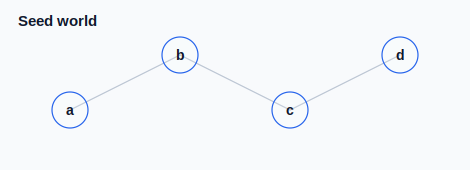

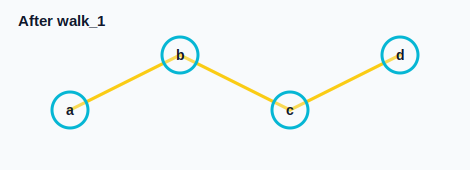

In [3]:

# Visualize the world before and after the walk.
display_svg(world_svg(seed_world, "Seed world"))
display_svg(world_svg(world, "After walk_1"))


## 3. Objects, Properties, and Addresses

Let $O$ be the set of addressable objects in the world.

Examples:

```text
node:a
node:b
edge:a-b
label:title
axis:x
plane:main
vector:v
region:R
```

Let $P$ be the set of properties that can be read or changed.

Examples:

```text
stroke_color
fill_color
stroke_width
fill_opacity
radius
scale
position
z_index
label_text
visibility
```

Properties may be flat or nested. A nested property is a path:

```text
eyes.color
transform.scale.x
style.stroke.width
```

Formally, a property path may be treated as a tuple:

$$
p = (p_1, p_2, \ldots, p_m)
$$

For example:

$$
\text{eyes.color} \equiv (\text{eyes}, \text{color})
$$

A state address is a pair:

$$
a = (o, p)
$$

where $o \in O$ is an object id and $p \in P$ is a property path.

In implementation-oriented notation:

```text
address = (object_id, property_path)
```

Examples:

```text
(node:a, stroke_color)
(node:a, radius)
(edge:a-b, stroke_width)
(label:title, opacity)
```

This address is the smallest unit of tracked state.

The key idea is that rollback should operate at the address level, not at the
object level.

If `node:a.color` changes but `node:a.radius` does not, then rollback should
only restore `node:a.color`.


## 4. World State

A world state is a mapping from addresses to values.

$$
W_t : A \to V
$$

Here $A$ is the set of state addresses and $V$ is the set of possible values.
The value set $V$ may contain colors, numbers, vectors, strings, booleans,
style objects, or structured values.

For example:

```text
W_0 = {
  (node:a, stroke_color): BLUE,
  (node:a, radius): 0.23,
  (edge:a-b, stroke_color): GRAY,
  (edge:a-b, stroke_width): 1.2
}
```

The world does not need to be represented as one giant object. It may be a
logical view over live objects in a renderer. What matters is that the system
can read and write values by address.

When a single address is read, we write:

$$
W_t(a) = v
$$

This means that at tick $t$, address $a$ has value $v$.


## 5. Commands

A command is a human-facing instruction.

Example:

```json
{
  "target": "node:a",
  "action": "set",
  "value": {
    "stroke_color": "CYAN",
    "stroke_width": 3.0
  }
}
```

Commands may be semantic, compact, and convenient. They do not need to expose
the internal ledger format.

For graph theory, examples include:

```json
{
  "walk": ["a", "b", "c"],
  "action": "highlight"
}
```

```json
{
  "edge": ["a", "b"],
  "action": "hit_release",
  "value": {
    "stroke_color": "YELLOW"
  }
}
```

The command layer is expressive. The ledger layer is exact.


## 6. Transition Records

Each command is resolved against the current world state.

Resolution means:

```text
read current value
compute new value
record old_value -> new_value
apply new value
```

A transition record has this shape:

$$
\tau = (t, a, v^{-}, v^{+}, m)
$$

where:

$$
\begin{aligned}
t &= \text{the tick where the transition occurs} \\
a &= \text{the state address} \\
v^{-} &= \text{the value before the transition} \\
v^{+} &= \text{the value after the transition} \\
m &= \text{optional metadata}
\end{aligned}
$$

In implementation-oriented notation:

```text
Transition = {
  tick,
  address,
  old_value,
  new_value,
  command_id,
  metadata
}
```

Example:

```json
{
  "tick": 7,
  "address": ["node:a", "stroke_color"],
  "old_value": "BLUE",
  "new_value": "CYAN",
  "command_id": "cmd_042",
  "metadata": {
    "source": "walk_player",
    "semantic_action": "highlight_vertex"
  }
}
```

The required fields are:

```text
tick
address
old_value
new_value
```

The optional fields help debugging, replay, grouping, provenance, and higher
level analysis.

The required invariant is:

$$
v^{-} = W_t(a)
$$

That is, the recorded old value must match the actual value of address $a$
immediately before the transition is applied.


## 7. Sparse Delta

A local delta is the set of transitions produced by one tick.

$$
\delta_t =
\left\{
  a_k : v_{k,t}^{-} \to v_{k,t}^{+}
\right\}_{k=1}^{r_t}
$$

Here $r_t$ is the number of addresses changed at tick $t$.

Only changed addresses are stored.

If a tick does not touch `node:a.radius`, then `node:a.radius` does not appear
in $\delta_t$.

The next world state is:

$$
W_{t+1} = W_t \oplus \delta_t
$$

Where:

$$
W_{t+1}(a) =
\begin{cases}
v^{+}, & \text{if } a \text{ appears in } \delta_t \\
W_t(a), & \text{otherwise}
\end{cases}
$$

This is the sparse override rule.

The symbol $\delta_t$ is local. It describes one tick.

The symbol $\Delta_{i \to k}$ is global over an interval. It describes the
compressed jump from world $W_i$ to world $W_k$:

$$
W_k = W_i \oplus \Delta_{i \to k}
$$

So:

```text
delta_t          = one tick of sparse changes
Delta_{i -> k}   = compressed jump across many ticks
```


## 8. Ticks

A tick is a discrete step in the animation timeline.

```text
Tick_t = [command_1, command_2, ..., command_n]
```

Commands inside the same tick are considered simultaneous from the perspective
of the timeline.

For animation, this usually means:

```text
all visual changes inside the tick are played together
then the system advances to the next tick
```

Example:

```json
{
  "tick": 4,
  "commands": [
    {
      "target": "node:a",
      "action": "set",
      "value": {
        "stroke_color": "CYAN"
      }
    },
    {
      "target": "edge:a-b",
      "action": "set",
      "value": {
        "stroke_color": "CYAN"
      }
    }
  ]
}
```

This describes a parallel visual update.


## 9. Conflict Policy

Two commands in the same tick may attempt to write the same address.

Example:

```text
tick 4:
  node:a.stroke_color = CYAN
  node:a.stroke_color = RED
```

This is a conflict because both commands write:

```text
(node:a, stroke_color)
```

Possible policies:

```text
reject
last_writer_wins
first_writer_wins
ordered_subticks
custom_merge
```

Recommended default:

```text
reject
```

Reason: in mathematical animation, hidden conflicts are usually mistakes.

If the user wants sequential writes inside one conceptual moment, the model can
introduce subticks:

```text
tick 4.1: node:a.stroke_color = CYAN
tick 4.2: node:a.stroke_color = RED
```

Or it can keep integer ticks and use command order explicitly:

```text
tick 4:
  mode: ordered
```

The cleanest default is:

```text
parallel tick writes must have disjoint addresses
```


In [4]:

# Same-tick conflict policy: two commands try to write the same address.
conflict_world = deepcopy(seed_world)
conflict_ledger = []

try:
    apply_tick(
        conflict_world,
        conflict_ledger,
        99,
        [
            {"action": "set", "target": "node:a", "value": {"stroke_color": "CYAN"}},
            {"action": "set", "target": "node:a", "value": {"stroke_color": "RED"}},
        ],
    )
except ValueError as error:
    print(error)


conflict at tick 99: duplicate write to ('node:a', 'stroke_color')


## 10. Interval Compression and Rollback Query

The ledger can answer a forward compression query:

$$
\operatorname{compress}(L, i, k) = \Delta_{i \to k}
$$

where $L$ is the ledger and $i < k$.

When the desired jump length is $j$, we set:

$$
k = i + j
$$

For example, if $j = 30$, then:

$$
\Delta_{i \to i+30}
$$

is the compressed state transition from $W_i$ to $W_{i+30}$.

The goal is to compress many local tick deltas:

$$
\delta_i, \delta_{i+1}, \ldots, \delta_{k-1}
$$

into one interval delta:

$$
\Delta_{i \to k}
$$

This interval delta should satisfy:

$$
W_k = W_i \oplus \Delta_{i \to k}
$$

For each address $a$, the interval compression keeps:

```text
first old value for address a in the interval
last new value for address a in the interval
```

So if one address changes as:

$$
\text{red} \to \text{brown} \to \text{yellow} \to \text{orange}
$$

then the compressed interval transition is:

$$
\text{red} \to \text{orange}
$$

The middle values are not lost from the ledger. They are only omitted from this
particular interval query.

For example, if an address moves through:

$$
\text{red} \to \text{orange} \to \text{red} \to \text{orange}
$$

then the ledger still preserves all three transitions in order. The compressed
interval jump is only:

$$
\text{red} \to \text{orange}
$$

because that is enough to transform the starting world $W_i$ into the ending
world $W_k$. If the goal is to replay the motion, use the ordered ledger. If the
goal is to jump state, use the compressed interval delta.

Formally, the ledger $L$ should be treated as an ordered sequence of transition
records, not as a mathematical set. This matters because repeated transitions
and their order can be meaningful.

Let:

$$
L = (\tau_1,\tau_2,\ldots,\tau_n)
$$

Then the interval sub-ledger is the ordered subsequence:

$$
L_{[i,k)}
=
(\tau_q \in L : i \leq \tau_q.t < k)
$$

The set of touched addresses is:

$$
A_{i \to k} = \{ \tau.a : \tau \in L_{[i,k)} \}
$$

This address set is only a projection that says which addresses were touched.
It intentionally drops value information. The value information is recovered by
looking back into the ordered transitions for each address.

For a specific address $a$, define the address sub-ledger:

$$
L_{[i,k)}^{a}
=
(\tau \in L_{[i,k)} : \tau.a = a)
$$

For each touched address $a \in A_{i \to k}$, define:

$$
\operatorname{firstOld}(a, i, k)
$$

as the $v^{-}$ of the first transition for $a$ in $L_{[i,k)}$.

Also define:

$$
\operatorname{lastNew}(a, i, k)
$$

as the $v^{+}$ of the last transition for $a$ in $L_{[i,k)}$.

Then the compressed interval delta is:

$$
\Delta_{i \to k}
=
\left\{
  a :
  \operatorname{firstOld}(a,i,k)
  \to
  \operatorname{lastNew}(a,i,k)
  \mid
  a \in A_{i \to k}
\right\}
$$

If:

$$
\operatorname{firstOld}(a,i,k)
=
\operatorname{lastNew}(a,i,k)
$$

then the address may be omitted from the compressed delta, because the net
effect is no change.

Example:

```text
tick 10: node:a.color red -> brown
tick 11: node:a.color brown -> yellow
tick 12: node:a.color yellow -> orange
```

The compressed jump from $W_{10}$ to $W_{13}$ is:

```text
node:a.color red -> orange
```

This can be read as:

$$
\Delta_{10 \to 13}(\text{node:a.color})
=
\text{red} \to \text{orange}
$$

The same idea as a diagram:

```mermaid
flowchart LR
    Wi["$$W_i$$"]
    d1["$$\delta_i$$"]
    d2["$$\delta_{i+1}$$"]
    dots["$$\cdots$$"]
    dj["$$\delta_{i+j-1}$$"]
    Wj["$$W_{i+j}$$"]
    Jump["$$\Delta_{i \to i+j}$$"]

    Wi --> d1 --> d2 --> dots --> dj --> Wj
    Wi -. compressed interval jump .-> Jump -.-> Wj
```

The top path is the full tick-by-tick history. The dotted lower path is the
compressed query result.

### 10.1 Compression Algorithm

The compression algorithm does not need to materialize every full world state.
It only needs the ledger records in the interval.

```text
function compress_interval(ledger, start_tick, end_tick):
    first_old_by_address = {}
    last_new_by_address = {}

    for transition in ledger:
        if transition.tick < start_tick:
            continue

        if transition.tick >= end_tick:
            continue

        address = transition.address

        if address not in first_old_by_address:
            first_old_by_address[address] = transition.old_value

        last_new_by_address[address] = transition.new_value

    delta = []

    for address in first_old_by_address:
        old_value = first_old_by_address[address]
        new_value = last_new_by_address[address]

        if old_value == new_value:
            continue

        delta.append({
            "address": address,
            "old_value": old_value,
            "new_value": new_value
        })

    return delta
```

This algorithm is linear in the number of transition records in the queried
interval:

$$
O(|L_{[i,k)}|)
$$

The memory required is proportional to the number of distinct changed
addresses:

$$
O(|A_{i \to k}|)
$$

### 10.2 Forward Jump Versus Rollback

Forward compression answers:

$$
W_i \to W_k
$$

Rollback answers:

$$
W_k \to W_i
$$

If:

$$
\Delta_{i \to k}
=
\{ a : v_a^{-} \to v_a^{+} \}
$$

then the rollback delta is:

$$
\Delta^{-1}_{i \to k}
=
\{ a : v_a^{+} \to v_a^{-} \}
$$

In practice, rollback may use the current value at address $a$ as the left side,
because the world may have advanced after $k$:

$$
a : W_{\mathrm{current}}(a) \to v_a^{-}
$$

This lets the system restore the interval origin even if there were intermediate
or later visual states.

Given the same half-open interval:

$$
[i,k)
$$

The changed address set is:

$$
\operatorname{Changed}(i,k)
=
\{ a \mid a \text{ appears in some } \delta_t
\text{ for } i \leq t < k \}
$$

For every changed address, define its origin value in the interval:

$$
\operatorname{Origin}(a,i,k)
=
\text{the } v^{-}
\text{ of the first transition for } a
\text{ in } [i,k)
$$

Then rollback is:

$$
\operatorname{Rollback}(i,k)
=
\left\{
  a :
  W_{\mathrm{current}}(a)
  \to
  \operatorname{Origin}(a,i,k)
  \mid
  a \in \operatorname{Changed}(i,k)
\right\}
$$

This rollback patch restores the world to the state it had before the interval
began, for all properties touched inside the interval.


In [5]:

# Compress the full walk interval: Delta_{1 -> 8}.
compressed = compress_interval(ledger, 1, 8)

print(f"raw transitions in walk ledger: {len(ledger)}")
print(f"compressed walk interval transitions: {len(compressed)}")
table(transition_rows(compressed))

# A tiny repeated-address example shows the real compression effect.
address = ("node:a", "stroke_color")
toy_ledger = [
    Transition(10, address, "RED", "BROWN"),
    Transition(11, address, "BROWN", "YELLOW"),
    Transition(12, address, "YELLOW", "ORANGE"),
]

toy_compressed = compress_interval(toy_ledger, 10, 13)
print("\nRepeated-address compression:")
table(transition_rows(toy_ledger))
print("compresses to:")
table(transition_rows(toy_compressed))


raw transitions in walk ledger: 21
compressed walk interval transitions: 21
tick     | address               | old  | new    | source
---------+-----------------------+------+--------+-------
interval | node:a.stroke_color   | BLUE | CYAN   | None  
interval | node:a.stroke_width   | 1.2  | 3.0    | None  
interval | node:a.fill_opacity   | 0.12 | 0.28   | None  
interval | edge:a-b.stroke_color | GRAY | YELLOW | None  
interval | edge:a-b.stroke_width | 1.2  | 3.2    | None  
interval | edge:a-b.opacity      | 0.6  | 1.0    | None  
interval | node:b.stroke_color   | BLUE | CYAN   | None  
interval | node:b.stroke_width   | 1.2  | 3.0    | None  
interval | node:b.fill_opacity   | 0.12 | 0.28   | None  
interval | edge:b-c.stroke_color | GRAY | YELLOW | None  
interval | edge:b-c.stroke_width | 1.2  | 3.2    | None  
interval | edge:b-c.opacity      | 0.6  | 1.0    | None  
interval | node:c.stroke_color   | BLUE | CYAN   | None  
interval | node:c.stroke_width   | 1.2  | 3.0    | Non

rollback patch entries: 21
address               | current | restore
----------------------+---------+--------
node:a.stroke_color   | CYAN    | BLUE   
node:a.stroke_width   | 3.0     | 1.2    
node:a.fill_opacity   | 0.28    | 0.12   
edge:a-b.stroke_color | YELLOW  | GRAY   
edge:a-b.stroke_width | 3.2     | 1.2    
edge:a-b.opacity      | 1.0     | 0.6    
node:b.stroke_color   | CYAN    | BLUE   
node:b.stroke_width   | 3.0     | 1.2    
node:b.fill_opacity   | 0.28    | 0.12   
edge:b-c.stroke_color | YELLOW  | GRAY   
edge:b-c.stroke_width | 3.2     | 1.2    
edge:b-c.opacity      | 1.0     | 0.6    
node:c.stroke_color   | CYAN    | BLUE   
node:c.stroke_width   | 3.0     | 1.2    
node:c.fill_opacity   | 0.28    | 0.12   
edge:c-d.stroke_color | YELLOW  | GRAY   
edge:c-d.stroke_width | 3.2     | 1.2    
edge:c-d.opacity      | 1.0     | 0.6    
node:d.stroke_color   | CYAN    | BLUE   
node:d.stroke_width   | 3.0     | 1.2    
node:d.fill_opacity   | 0.28    | 0.12   
restore

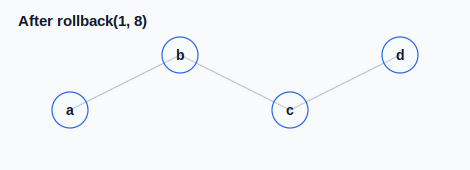

In [6]:

# Roll back the whole walk interval by restoring the first old value per touched address.
patch = rollback_patch(ledger, world, 1, 8)
restored_world = deepcopy(world)
apply_value_patch(restored_world, patch)

print(f"rollback patch entries: {len(patch)}")
table(patch_rows(patch))
print("restored equals seed:", restored_world == seed_world)
display_svg(world_svg(restored_world, "After rollback(1, 8)"))


## 11. Why Rollback Uses The First Old Value

Suppose this happened:

```text
tick 1: node:a.color BLUE -> RED
tick 2: node:a.color RED -> BROWN
tick 3: node:a.color BROWN -> WHITE
```

The complete path is:

```text
BLUE -> RED -> BROWN -> WHITE
```

If we rollback from tick 1 through tick 3, the correct restoration target is:

```text
BLUE
```

The intermediate values are useful history, but they are not rollback targets
for the whole interval.

This means rollback is not:

```text
undo the last transition only
```

It is:

```text
restore the left boundary of the interval
```

That is why the first old value is the important value.


## 12. Matrix View

The ledger can be visualized as a sparse matrix.

Rows are ticks.

Columns are state addresses.

Cells are transitions.

$$
\begin{array}{c|ccc}
 & a_1=\text{node:a.color}
 & a_2=\text{node:a.radius}
 & a_3=\text{edge:a-b.color}
\\
\hline
t_1
& \text{BLUE}\to\text{RED}
& \varnothing
& \varnothing
\\
t_2
& \text{RED}\to\text{BROWN}
& 0.23\to0.30
& \varnothing
\\
t_3
& \varnothing
& 0.30\to0.20
& \text{GRAY}\to\text{CYAN}
\\
t_4
& \text{BROWN}\to\text{WHITE}
& \varnothing
& \text{CYAN}\to\text{GRAY}
\end{array}
$$

Rollback from tick 1 to tick 4 reads the first left-side value in each touched
column:

$$
\begin{aligned}
a_1 &\mapsto \text{BLUE} \\
a_2 &\mapsto 0.23 \\
a_3 &\mapsto \text{GRAY}
\end{aligned}
$$

The matrix is sparse because empty cells are not stored.

The physical storage is more likely to be a list:

```text
[
  (1, node:a.color, BLUE, RED),
  (2, node:a.color, RED, BROWN),
  (2, node:a.radius, 0.23, 0.30),
  (3, node:a.radius, 0.30, 0.20),
  (3, edge:a-b.color, GRAY, CYAN),
  (4, node:a.color, BROWN, WHITE),
  (4, edge:a-b.color, CYAN, GRAY)
]
```

The matrix view is conceptual. The ledger is compact.


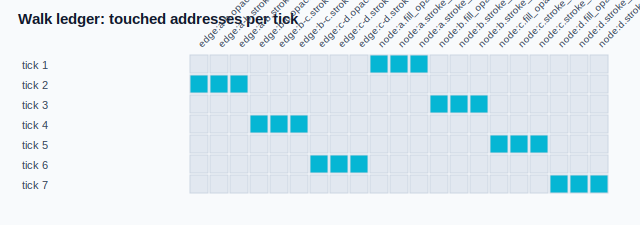

In [ ]:

# Visualize the sparse matrix: rows are ticks, columns are changed addresses.
display_svg(ledger_heatmap_svg(ledger, "Walk ledger: touched addresses per tick"))

## 13. Seed State

The seed state is the initial world.

$$
W_{\mathrm{seed}}
$$

For a graph animation, it may contain:

```text
node ids
node positions
node labels
node radius
node stroke colors
node fill colors
edge endpoints
edge direction
edge curvature
edge stroke color
edge stroke width
label styles
z-index rules
```

The seed state should be complete enough that the world can be rebuilt from it.

The full animated history is:

$$
\text{World} = W_{\mathrm{seed}} + L
$$

If the seed is stable and the ledger is complete, the animation is reproducible.


## 14. Checkpoints

A checkpoint names a tick.

```text
checkpoint "clean_graph" = tick 0
checkpoint "after_first_walk" = tick 13
checkpoint "before_cycle" = tick 20
```

A checkpoint does not need to store a full copy of the world. It can simply
store a pointer to a tick.

Rollback to a checkpoint becomes:

```text
rollback(current_tick, checkpoint_tick)
```

If the system wants faster random access, it may optionally store full snapshots
at selected checkpoints.

This creates a hybrid model:

```text
rare full snapshots + dense sparse ledger
```

But the core theory does not require full snapshots.


## 15. Replay

To replay the world from the seed:

```text
W = W_seed
for each tick in order:
  delta_t = resolve(commands_t, W)
  W = apply(W, delta_t)
```

If the ledger already exists, replay can skip command resolution:

```text
W = W_seed
for each transition in ledger order:
  W[address] = new_value
```

This distinction is important:

```text
commands are semantic
ledger entries are resolved facts
```

Commands may depend on high-level logic.

Ledger entries are direct state changes.


## 16. Forward Patch and Inverse Patch

A forward patch applies new values:

$$
P^{+} = \{ a : v^{+} \mid a \in A' \}
$$

An inverse patch restores previous values:

$$
P^{-} = \{ a : v^{-} \mid a \in A' \}
$$

Here $A'$ is the subset of addresses touched by the patch.

For a single tick, inverse is simple:

$$
\operatorname{inverse}(\delta_t)
=
\{ a : v^{-} \mid a : v^{-} \to v^{+} \in \delta_t \}
$$

For an interval, inverse must compress multiple transitions per address:

$$
\operatorname{inverse}(\Delta_{i \to k})
=
\{ a : \operatorname{firstOld}(a,i,k) \mid a \in A_{i \to k} \}
$$

This is the central compression rule.


## 17. Difference From Simple Undo

Simple undo usually reverses the last operation.

The Sparse Ticker State Ledger can do that, but it is more general.

It can answer:

```text
restore the last tick
restore the last walk
restore everything since checkpoint X
restore only node colors since tick 5
restore only edge widths in the current interval
```

Because the ledger is queryable by:

```text
tick range
object id
property
command id
semantic source
```

Rollback becomes a query problem, not only a stack pop.


## 18. Selective Rollback

The rollback query can be filtered.

Examples:

```text
rollback only node colors
rollback only edge highlights
rollback only objects touched by walk_3
rollback only opacity changes
```

Formally:

$$
\operatorname{Rollback}(t_i,t_j,f)
=
\left\{
  a : \operatorname{firstOld}(a,t_i,t_j)
  \mid
  a \in A_{i \to j}
  \land f(a,m)=\mathrm{true}
\right\}
$$

This makes the model useful for layered animation systems.

For example, a graph could keep permanent topology changes while rolling back
temporary visual highlights.


node-only rollback patch entries: 12
address             | current | restore
--------------------+---------+--------
node:a.stroke_color | CYAN    | BLUE   
node:a.stroke_width | 3.0     | 1.2    
node:a.fill_opacity | 0.28    | 0.12   
node:b.stroke_color | CYAN    | BLUE   
node:b.stroke_width | 3.0     | 1.2    
node:b.fill_opacity | 0.28    | 0.12   
node:c.stroke_color | CYAN    | BLUE   
node:c.stroke_width | 3.0     | 1.2    
node:c.fill_opacity | 0.28    | 0.12   
node:d.stroke_color | CYAN    | BLUE   
node:d.stroke_width | 3.0     | 1.2    
node:d.fill_opacity | 0.28    | 0.12   


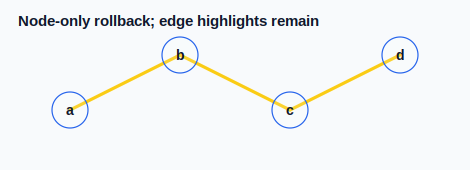

In [7]:

# Selective rollback: restore only node properties, leaving edge highlights in place.
node_only = lambda transition: transition.address[0].startswith("node:")
node_patch = rollback_patch(ledger, world, 1, 8, predicate=node_only)
node_restored_world = deepcopy(world)
apply_value_patch(node_restored_world, node_patch)

print(f"node-only rollback patch entries: {len(node_patch)}")
table(patch_rows(node_patch))
display_svg(world_svg(node_restored_world, "Node-only rollback; edge highlights remain"))


## 19. Graph Theory Application

In a graph animation, the base topology is the seed world.

```text
G = (V, E)
```

The visual graph adds state:

```text
position(v)
radius(v)
label(v)
stroke_color(v)
fill_color(v)
stroke_width(v)
stroke_color(e)
stroke_width(e)
opacity(e)
```

A walk:

```text
a -> b -> c -> d
```

is a semantic object.

It can generate commands:

```text
tick 1: hit node:a
tick 2: hit edge:a-b
tick 3: hit node:b
tick 4: hit edge:b-c
tick 5: hit node:c
tick 6: hit edge:c-d
tick 7: hit node:d
```

Each hit command resolves into property transitions.

Example:

```text
hit node:a
```

becomes:

```text
(node:a, stroke_color): BLUE -> CYAN
(node:a, stroke_width): 1.2 -> 3.0
(node:a, fill_opacity): 0.12 -> 0.28
```

When the walk is finished, rollback can restore exactly the properties touched
by that walk.

The graph does not need duplicate walk edges. The walk operates on the existing
topology.


## 20. Parallel Walks

Multiple walks can run at the same time if their writes do not conflict.

Example:

```text
tick 10:
  walk_A highlights node:a
  walk_B highlights node:x
```

This is safe if they touch disjoint addresses.

Conflict:

```text
tick 10:
  walk_A sets node:a.stroke_color to CYAN
  walk_B sets node:a.stroke_color to RED
```

Possible solutions:

```text
reject the conflict
use layers
compose highlights
split into subticks
define priority
```

A layered approach can avoid conflicts by changing the address model:

```text
(node:a, highlight_layer:walk_A, color)
(node:a, highlight_layer:walk_B, color)
```

Then rendering combines layers into final appearance.

This is more complex, but it allows multiple semantic processes to affect the
same visible object without overwriting each other directly.


## 21. State Restoration Styles

There are several restoration styles.

### 21.1 Hard Restore

Immediately set values back.

```text
node:a.color = BLUE
```

### 21.2 Animated Restore

Animate values back.

```text
node:a.color: CYAN -> BLUE over 0.4 seconds
```

### 21.3 Semantic Release

Use a named behavior that resolves into restore commands.

```text
release node:a
```

The ledger model supports all three because each one becomes a transition.


## 22. Important Invariant

For every transition:

```text
address: old_value -> new_value
```

The old value must equal the actual world value at that address immediately
before the transition is applied.

Formally:

$$
v^{-} = W_t(a)
$$

If this invariant is broken, rollback becomes unreliable.

Therefore, command resolution must read the current state before writing.


## 23. Idempotent No-Ops

If a command sets a property to its current value:

```text
node:a.color BLUE -> BLUE
```

The system can either store it or skip it.

Recommended default:

```text
skip no-op transitions
```

Reason: the ledger should represent real change.

However, metadata-only commands may still be useful for markers:

```text
tick 12: "walk_1_completed"
```

These are events, not state transitions.


## 24. Events Versus Transitions

The ledger may contain two related things:

```text
events
transitions
```

Events record that something happened.

```text
walk_1 started
walk_1 completed
cycle detected
vertex visited
```

Transitions record state changes.

```text
node:a.color BLUE -> CYAN
edge:a-b.width 1.2 -> 3.0
```

Events are useful for narrative and debugging.

Transitions are required for state restoration.


## 25. Minimal Data Structures

A minimal implementation needs:

```text
WorldState:
  address -> value

Transition:
  tick
  address
  old_value
  new_value

Ledger:
  list of transitions

Tick:
  list of commands
```

Optional extensions:

```text
command_id
source
semantic_action
duration
easing
layer
checkpoint
tags
```


In [8]:

# Minimal data structures in action.
print(type(seed_world).__name__, "address -> value entries:", len(seed_world))
print(type(ledger).__name__, "transition records:", len(ledger))
print(type(ticks).__name__, "ticks:", len(ticks))

sample_address = ("node:a", "stroke_color")
print("sample address:", sample_address)
print("seed value:", seed_world[sample_address])
print("current value:", world[sample_address])


dict address -> value entries: 40
list transition records: 21
list ticks: 7
sample address: ('node:a', 'stroke_color')
seed value: BLUE
current value: CYAN


## 26. Pseudocode: Applying Commands

```text
function apply_tick(world, tick, commands):
    delta = []
    writes = set()

    for command in commands:
        proposed_changes = resolve(command, world)

        for change in proposed_changes:
            if change.address in writes:
                raise ConflictError(change.address)

            writes.add(change.address)
            old_value = world[change.address]
            new_value = change.new_value

            if old_value == new_value:
                continue

            transition = Transition(
                tick=tick,
                address=change.address,
                old_value=old_value,
                new_value=new_value
            )

            delta.append(transition)

    for transition in delta:
        world[transition.address] = transition.new_value

    ledger.append(delta)
    return delta
```


## 27. Pseudocode: Rollback Patch

```text
function rollback_patch(ledger, start_tick, end_tick, filter=None):
    first_old_by_address = {}

    for transition in ledger:
        if transition.tick < start_tick:
            continue

        if transition.tick > end_tick:
            continue

        if filter is not None and not filter(transition):
            continue

        if transition.address not in first_old_by_address:
            first_old_by_address[transition.address] = transition.old_value

    patch = []

    for address, origin_value in first_old_by_address.items():
        patch.append({
            "address": address,
            "value": origin_value
        })

    return patch
```


## 28. Pseudocode: Applying Rollback

```text
function apply_patch(world, patch):
    delta = []

    for item in patch:
        address = item.address
        new_value = item.value
        old_value = world[address]

        if old_value == new_value:
            continue

        transition = Transition(
            tick=current_tick(),
            address=address,
            old_value=old_value,
            new_value=new_value,
            metadata={
                "source": "rollback"
            }
        )

        world[address] = new_value
        delta.append(transition)

    ledger.append(delta)
    return delta
```

Important: rollback itself can be recorded as a new transition. This makes the
world history honest and auditable.


## 29. Naming

Possible names for this theory:

```text
Sparse Ticker State Ledger
Sparse Transition Ledger
Ticker State Ledger
Interval Rollback Ledger
Sparse World Ledger
Command Resolved State Ledger
```

Preferred name:

```text
Sparse Ticker State Ledger
```

Reason:

```text
Sparse
  It stores only what changed.

Ticker
  The world advances through discrete ticks.

State
  The tracked content is world state.

Ledger
  The history is an append-only record of transitions.
```


## 30. Final Definition

The Sparse Ticker State Ledger is a tuple:

$$
M = (W_{\mathrm{seed}}, T, C, L, Q)
$$

Where:

$$
\begin{aligned}
W_{\mathrm{seed}} &= \text{initial world state} \\
T &= \text{ordered set of ticks} \\
C &= \text{command resolver} \\
L &= \text{sparse transition ledger} \\
Q &= \text{query system for compression, rollback, replay, and inspection}
\end{aligned}
$$

The main forward operation is:

$$
\begin{aligned}
C(c,W_t) &\to \delta_t \\
W_{t+1} &= W_t \oplus \delta_t \\
L &\leftarrow L \cup \delta_t
\end{aligned}
$$

The main interval compression operation is:

$$
\operatorname{compress}(L,i,k) \to \Delta_{i \to k}
$$

The main rollback operation is:

$$
\operatorname{rollback}(i,k)
\to
\Delta^{-1}_{i \to k}
$$

For each address changed in $[i,k)$, rollback restores the first old value
observed for that address in the interval.

The model is compact because it does not store repeated full snapshots.

The model is reversible because every transition records both sides:

$$
v^{-} \to v^{+}
$$

The model is expressive because semantic commands can be compiled into exact
state transitions.

The model is useful for animation because visual effects, walks, highlights,
algorithm traces, and releases can all be represented as commands over a
queryable sparse state ledger.
